In [9]:
import sys
import os

sys.path.append(
    os.path.abspath("../../src")
)

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("../../data/raw/AmesHousing.csv")

df_fe = df.copy()

# Remove identifiers
df_fe = df_fe.drop(columns=["Order", "PID"])

# Feature engineering
df_fe["TotalSF"] = (
    df_fe["Total Bsmt SF"]
    + df_fe["1st Flr SF"]
    + df_fe["2nd Flr SF"]
)

df_fe["TotalBathrooms"] = (
    df_fe["Full Bath"]
    + 0.5 * df_fe["Half Bath"]
    + df_fe["Bsmt Full Bath"]
    + 0.5 * df_fe["Bsmt Half Bath"]
)

df_fe["TotalPorchSF"] = (
    df_fe["Wood Deck SF"]
    + df_fe["Open Porch SF"]
    + df_fe["Enclosed Porch"]
    + df_fe["3Ssn Porch"]
    + df_fe["Screen Porch"]
)

df_fe["TotalBsmtFinSF"] = (
    df_fe["BsmtFin SF 1"]
    + df_fe["BsmtFin SF 2"]
)

df_fe["HouseAge"] = (
    df_fe["Yr Sold"] - df_fe["Year Built"]
).clip(lower=0)

df_fe["YearsSinceRemodel"] = (
    df_fe["Yr Sold"] - df_fe["Year Remod/Add"]
).clip(lower=0)

df_fe["GarageAge"] = (
    df_fe["Yr Sold"] - df_fe["Garage Yr Blt"]
).clip(lower=0)

print("Shape:", df_fe.shape)
df_fe.head()

Shape: (2930, 87)


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Sale Type,Sale Condition,SalePrice,TotalSF,TotalBathrooms,TotalPorchSF,TotalBsmtFinSF,HouseAge,YearsSinceRemodel,GarageAge
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,WD,Normal,215000,2736.0,2.0,272,639.0,50,50,50.0
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,WD,Normal,105000,1778.0,1.0,260,612.0,49,49,49.0
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,WD,Normal,172000,2658.0,1.5,429,923.0,52,52,52.0
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,WD,Normal,244000,4220.0,3.5,0,1065.0,42,42,42.0
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,WD,Normal,189900,2557.0,2.5,246,791.0,13,12,13.0


In [2]:
df_fe["Log_SalePrice"] = np.log1p(df_fe["SalePrice"])

print("Original skewness:",
      df_fe["SalePrice"].skew())

print("Log skewness:",
      df_fe["Log_SalePrice"].skew())

Original skewness: 1.7435000757376466
Log skewness: -0.014772659537224368


In [3]:
X = df_fe.drop(
    columns=["SalePrice", "Log_SalePrice"]
)

y = df_fe["Log_SalePrice"]

In [4]:
print("X:", X.shape)
print("y:", y.shape)

X: (2930, 86)
y: (2930,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (2344, 86)
Testing : (586, 86)


## Preprocesssor

In [10]:
from preprocessing import build_preprocessor

preprocessor, numerical_features, categorical_features = (
    build_preprocessor(X_train)
)

print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))

Numerical: 43
Categorical: 43


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [12]:
from xgboost import XGBRegressor

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, model):
    model.fit(X_train,y_train)

    log_pred = model.predict(X_test)

    # Convert back to actual SalePrice
    y_pred = np.expm1(log_pred)
    y_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    print(f"\n======== {name} ========")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Ridge Regression

In [19]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=10))
    ]
)

ridge_result = evaluate_model(
    "Ridge Regression",
    ridge_model
)


======== Ridge Regression ========
MAE:  $15,559.20
RMSE: $31,877.70
R²   : 0.8733


## Random Forest

In [22]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300,max_depth=None,
                                        min_samples_split=2,random_state=42,n_jobs=-1))
])

rf_result = evaluate_model("Random Forest", rf_model)


======== Random Forest ========
MAE:  $15,594.47
RMSE: $25,978.89
R²   : 0.9158


## Gradient Boosting

In [24]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(n_estimators=300,learning_rate=0.03,
                                            max_depth=3,random_state=42))
])

gb_result = evaluate_model("Gradient Boosting", gb_model)


======== Gradient Boosting ========
MAE:  $14,647.56
RMSE: $25,293.40
R²   : 0.9202


## XGBoost

In [25]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(objective="reg:squarederror",n_estimators=1000,
                               learning_rate=0.03,max_depth=4,
                               min_child_weight=5,subsample=0.8,colsample_bytree=0.8,
                               reg_alpha=0.1,reg_lambda=1.0,tree_methord="hist",
                               random_state=42,n_jobs=-1))
])

xgb_result = evaluate_model("XGBoost", xgb_model)


======== XGBoost ========
MAE:  $13,188.49
RMSE: $21,447.45
R²   : 0.9426


In [26]:
results = pd.DataFrame([
    ridge_result,
    rf_result,
    gb_result,
    xgb_result
])

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,XGBoost,13188.491868,21447.452930,0.942627
2,Gradient Boosting,14647.564459,25293.396725,0.920206
1,Random Forest,15594.472954,25978.892622,0.915822
0,Ridge Regression,15559.198262,31877.700412,0.873255


In [35]:
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=700,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42
        ))
    ]
)

xgb_result = evaluate_model(
    "XGBoost",
    xgb_model
)


======== XGBoost ========
MAE:  $13,262.47
RMSE: $21,735.65
R²   : 0.9411


In [30]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    "regressor__n_estimators": [300, 500, 700, 1000, 1200],
    "regressor__learning_rate": [0.02, 0.03, 0.04, 0.05, 0.1, 0.003, 0.005, 0.025],
    "regressor__max_depth": [3, 4, 5],
    "regressor__min_child_weight": [1, 3, 5]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__learning_rate': [0.02, 0.03, ...], 'regressor__max_depth': [3, 4, ...], 'regressor__min_child_weight': [1, 3, ...], 'regressor__n_estimators': [300, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter

In [31]:
print("\n========== BEST XGBOOST PARAMETERS ==========")

print(xgb_grid.best_params_)

print("\nBest CV RMSE:")
print(-xgb_grid.best_score_)


========== BEST XGBOOST PARAMETERS ==========
{'regressor__learning_rate': 0.03, 'regressor__max_depth': 4, 'regressor__min_child_weight': 3, 'regressor__n_estimators': 1200}

Best CV RMSE:
0.12123439579641662


In [38]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = mean_squared_error(
    y_test,
    y_pred_xgb
) ** 0.5

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

print("\n========== TUNED XGBOOST ==========")

print(f"MAE  : ${mae_xgb:,.2f}")
print(f"RMSE : ${rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")


========== TUNED XGBOOST ==========
MAE  : $0.07
RMSE : $0.10
R²   : 0.9467


In [37]:
y = np.log1p(df["SalePrice"])

In [39]:
# Predictions are currently in log(SalePrice) space
y_pred_log = xgb_grid.best_estimator_.predict(X_test)

# Convert predictions back to original dollar scale
y_pred_original = np.expm1(y_pred_log)

# Actual prices must also be in original dollar scale
y_test_original = np.expm1(y_test)

# Metrics
mae_original = mean_absolute_error(
    y_test_original,
    y_pred_original
)

rmse_original = mean_squared_error(
    y_test_original,
    y_pred_original
) ** 0.5

r2_original = r2_score(
    y_test_original,
    y_pred_original
)

print("\n========== TUNED XGBOOST — ORIGINAL SCALE ==========")

print(f"MAE  : ${mae_original:,.2f}")
print(f"RMSE : ${rmse_original:,.2f}")
print(f"R²   : {r2_original:.4f}")


========== TUNED XGBOOST — ORIGINAL SCALE ==========
MAE  : $13,093.02
RMSE : $21,503.89
R²   : 0.9423


In [40]:
print(y_test.head())

1357    11.989166
2367    11.661354
2822    12.188423
2126    11.724814
1544    11.744045
Name: Log_SalePrice, dtype: float64


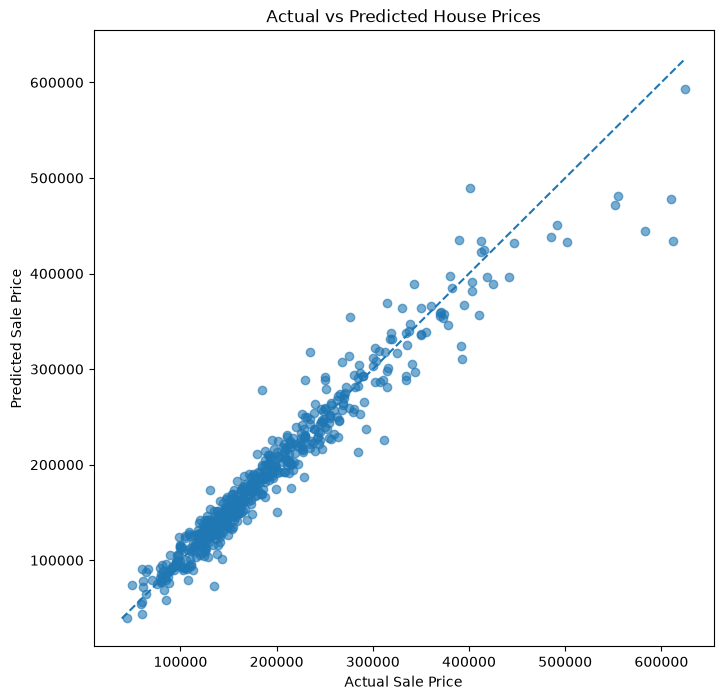

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_original,
    y_pred_original,
    alpha=0.6
)

# Perfect prediction line
min_price = min(
    y_test_original.min(),
    y_pred_original.min()
)

max_price = max(
    y_test_original.max(),
    y_pred_original.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [42]:
error_analysis = pd.DataFrame({
    "Actual": y_test_original.values,
    "Predicted": y_pred_original
})

error_analysis["Error"] = (
    error_analysis["Actual"]
    - error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"]
    / error_analysis["Actual"]
    * 100
)

error_analysis.head(10)

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
0,161000.0,149593.234375,11406.765625,11406.765625,7.084948
1,116000.0,103370.781250,12629.218750,12629.218750,10.887258
2,196500.0,186516.984375,9983.015625,9983.015625,5.080415
3,123600.0,117704.773438,5895.226563,5895.226563,4.769601
4,126000.0,113115.578125,12884.421875,12884.421875,10.225732
5,174190.0,171613.203125,2576.796875,2576.796875,1.479302
6,200000.0,150517.843750,49482.156250,49482.156250,24.741078
7,148500.0,146930.843750,1569.156250,1569.156250,1.056671
8,88750.0,88380.812500,369.187500,369.187500,0.415986
9,409900.0,356281.656250,53618.343750,53618.343750,13.080835


In [43]:
worst_predictions = (
    error_analysis
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

worst_predictions

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
173,611657.0,434308.656250,177348.343750,177348.343750,28.994738
450,582933.0,444501.593750,138431.406250,138431.406250,23.747396
511,610000.0,478312.218750,131687.781250,131687.781250,21.588161
89,184750.0,278159.750000,-93409.750000,93409.750000,50.560081
383,401179.0,489845.187500,-88666.187500,88666.187500,22.101403
473,311500.0,226075.890625,85424.109375,85424.109375,27.423470
117,235000.0,318040.500000,-83040.500000,83040.500000,35.336383
101,392500.0,310280.750000,82219.250000,82219.250000,20.947580
582,552000.0,471243.031250,80756.968750,80756.968750,14.629886
219,276000.0,354459.343750,-78459.343750,78459.343750,28.427298


In [44]:
xgb_estimator = (
    xgb_grid
    .best_estimator_
    .named_steps["regressor"]
)

In [45]:
feature_names = (
    xgb_grid
    .best_estimator_
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [46]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_estimator.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(20)

,Feature,Importance
3,numerical__Overall Qual,0.170249
36,numerical__TotalSF,0.076395
184,categorical__Exter Qual_TA,0.065208
233,categorical__Central Air_N,0.051088
196,categorical__Bsmt Qual_Ex,0.031566
25,numerical__Garage Cars,0.031158
37,numerical__TotalBathrooms,0.027977
276,categorical__Paved Drive_N,0.025013
23,numerical__Fireplaces,0.022533
265,categorical__Garage Finish_Unf,0.021176


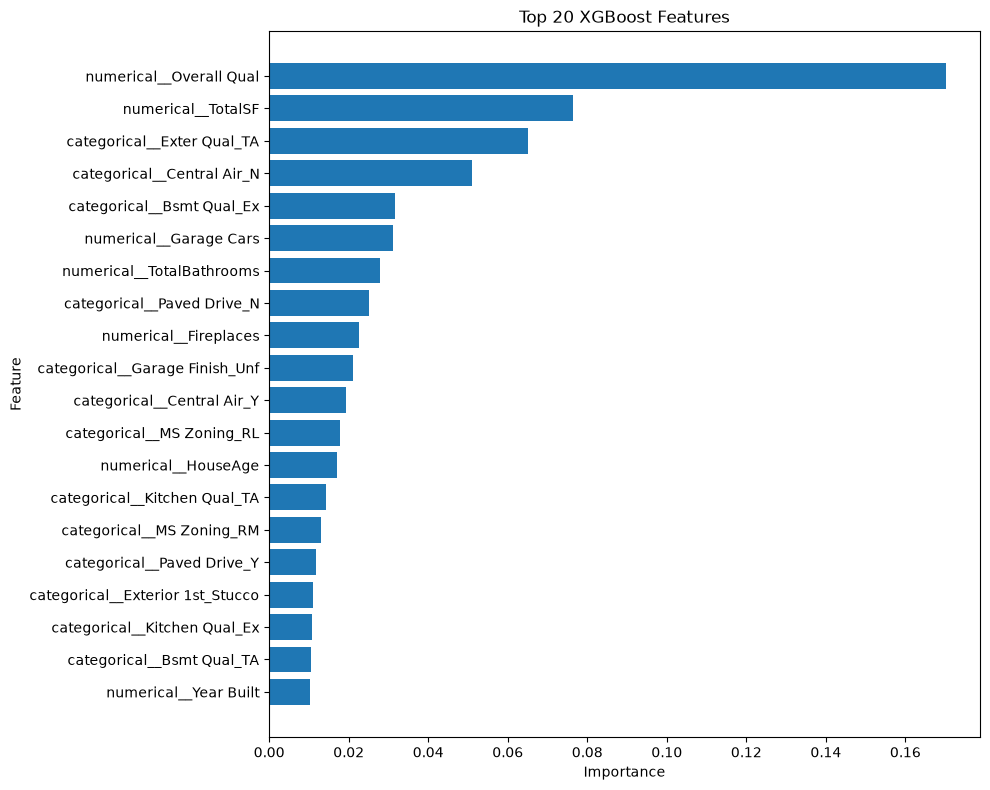

In [47]:
top_features = importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

In [48]:
# Check all engineered/log features
[col for col in df_fe.columns if "Log_" in col]

['Log_SalePrice']

In [51]:
from feature_engineering import create_features

test_df = create_features(df)

print("Original:", df.shape)
print("After feature engineering:", test_df.shape)

test_df.head()

Original: (2930, 82)
After feature engineering: (2930, 94)


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,HouseAge,YearsSinceRemodel,GarageAge,Log_Lot_Area,Log_TotalSF,Log_Gr_Liv_Area,Log_Total_Bsmt_SF,Log_1st_Flr_SF,Log_BsmtFin_SF_1,Log_TotalPorchSF
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,50,50,50.0,10.366309,7.914618,7.412764,6.985642,7.412764,6.461468,5.609472
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,49,49,49.0,9.360741,7.483807,6.799056,6.783325,6.799056,6.150603,5.564520
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,52,52,52.0,9.565775,7.885705,7.192934,7.192934,7.192934,6.828712,6.063785
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,42,42,42.0,9.320181,8.347827,7.654917,7.654917,7.654917,6.971669,0.000000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,13,12,13.0,9.534668,7.846981,7.396335,6.834109,6.834109,6.674561,5.509388
